# Telecom X – Parte 2: Predicción de Cancelación (Churn)

### Importando bibliotecas necesarias

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats

## 🛠️ Preparación de los Datos

In [2]:
# 1. Carga el DataFrame y elimina columnas irrelevantes
df = pd.read_csv('/content/datos_tratados.csv')
print("Columnas originales:", df.columns.tolist())
df = df.drop('customerID', axis=1)

Columnas originales: ['customerID', 'Evasion', 'Genero', 'CiudadanoMayor', 'Pareja', 'Dependientes', 'Antiguedad', 'ServicioTelefonico', 'LineasMultiples', 'ServicioInternet', 'SeguridadOnline', 'BackupOnline', 'ProteccionDispositivo', 'SoporteTecnico', 'StreamingTV', 'StreamingPeliculas', 'Contrato', 'FacturacionSinPapel', 'MetodoPago', 'CargosMensuales', 'CargosTotales', 'CargosDiarios']


In [3]:
print("Columnas originales:", df.columns.tolist())

Columnas originales: ['Evasion', 'Genero', 'CiudadanoMayor', 'Pareja', 'Dependientes', 'Antiguedad', 'ServicioTelefonico', 'LineasMultiples', 'ServicioInternet', 'SeguridadOnline', 'BackupOnline', 'ProteccionDispositivo', 'SoporteTecnico', 'StreamingTV', 'StreamingPeliculas', 'Contrato', 'FacturacionSinPapel', 'MetodoPago', 'CargosMensuales', 'CargosTotales', 'CargosDiarios']


In [4]:
# Manejo de nulls
df['CargosTotales'] = df['CargosTotales'].fillna(df['CargosTotales'].median())
print("Nulls después de imputación inicial:", df.isnull().sum().sum())

Nulls después de imputación inicial: 0


In [5]:
# Mejora: Análisis descriptivo inicial con statsmodels
desc = df.describe()
print("Análisis descriptivo:\n", desc)

Análisis descriptivo:
            Evasion  CiudadanoMayor       Pareja  Dependientes   Antiguedad  \
count  7043.000000     7043.000000  7043.000000   7043.000000  7043.000000   
mean      0.265370        0.162147     0.483033      0.299588    32.371149   
std       0.441561        0.368612     0.499748      0.458110    24.559481   
min       0.000000        0.000000     0.000000      0.000000     0.000000   
25%       0.000000        0.000000     0.000000      0.000000     9.000000   
50%       0.000000        0.000000     0.000000      0.000000    29.000000   
75%       1.000000        0.000000     1.000000      1.000000    55.000000   
max       1.000000        1.000000     1.000000      1.000000    72.000000   

       ServicioTelefonico  LineasMultiples  SeguridadOnline  BackupOnline  \
count         7043.000000      7043.000000      7043.000000   7043.000000   
mean             0.903166         0.421837         0.286668      0.344881   
std              0.295752         0.493888 

In [6]:
# Ajuste: Seleccionar columnas numéricas excluyendo 'Evasion' y manejando cualquier nan restante
num_cols = df.select_dtypes(include=['float64', 'int64']).drop('Evasion', axis=1)
num_cols = num_cols.fillna(num_cols.median())  # Doble chequeo por si hay nans en otras columnas
model_desc = sm.OLS(df['Evasion'], sm.add_constant(num_cols)).fit()
print(model_desc.summary())  # Resumen estadístico básico

                            OLS Regression Results                            
Dep. Variable:                Evasion   R-squared:                       0.272
Model:                            OLS   Adj. R-squared:                  0.271
Method:                 Least Squares   F-statistic:                     175.3
Date:                Wed, 11 Mar 2026   Prob (F-statistic):               0.00
Time:                        02:21:55   Log-Likelihood:                -3116.2
No. Observations:                7043   AIC:                             6264.
Df Residuals:                    7027   BIC:                             6374.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     0.20

In [7]:
# Mejora: Detección y manejo de outliers con Z-score
z_scores = np.abs(stats.zscore(df.select_dtypes(include=['float64', 'int64'])))
df = df[(z_scores < 3).all(axis=1)]  # Eliminar outliers extremos
print("Forma después de outliers:", df.shape)

Forma después de outliers: (6361, 21)


In [8]:
print("Forma del DataFrame después de eliminar columnas:", df.shape)
df.head()

Forma del DataFrame después de eliminar columnas: (6361, 21)


,Evasion,Genero,CiudadanoMayor,Pareja,Dependientes,Antiguedad,ServicioTelefonico,LineasMultiples,ServicioInternet,SeguridadOnline,...,ProteccionDispositivo,SoporteTecnico,StreamingTV,StreamingPeliculas,Contrato,FacturacionSinPapel,MetodoPago,CargosMensuales,CargosTotales,CargosDiarios
0,0.0,female,0,1.0,1.0,9,1.0,0.0,dsl,0.0,...,0.0,1.0,1.0,0.0,one_year,1.0,mailed_check,65.6,593.30,2.186667
1,0.0,male,0,0.0,0.0,9,1.0,1.0,dsl,0.0,...,0.0,0.0,0.0,1.0,month-to-month,0.0,mailed_check,59.9,542.40,1.996667
2,1.0,male,0,0.0,0.0,4,1.0,0.0,fiber_optic,0.0,...,1.0,0.0,0.0,0.0,month-to-month,1.0,electronic_check,73.9,280.85,2.463333
3,1.0,male,1,1.0,0.0,13,1.0,0.0,fiber_optic,0.0,...,1.0,0.0,1.0,1.0,month-to-month,1.0,electronic_check,98.0,1237.85,3.266667
4,1.0,female,1,1.0,0.0,3,1.0,0.0,fiber_optic,0.0,...,0.0,1.0,1.0,0.0,month-to-month,1.0,mailed_check,83.9,267.40,2.796667


In [9]:
# 2. Transforma variables categóricas a numéricas
# Usando OneHotEncoder en lugar de get_dummies para más control y manejando multicolinealidad con VIF
categorical_cols = ['Genero', 'ServicioInternet', 'Contrato', 'MetodoPago']
encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded = encoder.fit_transform(df[categorical_cols])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(categorical_cols))
df = pd.concat([df.drop(categorical_cols, axis=1).reset_index(drop=True), encoded_df.reset_index(drop=True)], axis=1)
print("Forma después de OneHotEncoder:", df.shape)

Forma después de OneHotEncoder: (6361, 25)


In [10]:
# Calculando VIF para manejo de multicolinealidad
X_vif = df.select_dtypes(include=['float64', 'int64']).drop('Evasion', axis=1)
X_vif = X_vif.fillna(X_vif.median())  # Asegurar no nans para VIF
vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]
print("VIF:\n", vif_data)  # Si VIF > 10, dropear features, if 'CargosDiarios' high, drop it
if 'CargosDiarios' in df.columns and vif_data[vif_data['feature'] == 'CargosDiarios']['VIF'].values[0] > 10:
    df = df.drop('CargosDiarios', axis=1)
df.head()

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


VIF:
                                feature          VIF
0                       CiudadanoMayor     1.155621
1                               Pareja     1.471307
2                         Dependientes     1.387870
3                           Antiguedad     7.868715
4                   ServicioTelefonico  1924.329794
5                      LineasMultiples     7.192918
6                      SeguridadOnline     6.152773
7                         BackupOnline     6.665019
8                ProteccionDispositivo     6.805900
9                       SoporteTecnico     6.215532
10                         StreamingTV    23.585063
11                  StreamingPeliculas    23.649995
12                 FacturacionSinPapel     1.220218
13                     CargosMensuales          inf
14                       CargosTotales    11.350591
15                       CargosDiarios          inf
16                         Genero_male     1.002672
17        ServicioInternet_fiber_optic   147.398295
18    

,Evasion,CiudadanoMayor,Pareja,Dependientes,Antiguedad,ServicioTelefonico,LineasMultiples,SeguridadOnline,BackupOnline,ProteccionDispositivo,...,CargosMensuales,CargosTotales,Genero_male,ServicioInternet_fiber_optic,ServicioInternet_no,Contrato_one_year,Contrato_two_year,MetodoPago_credit_card_(automatic),MetodoPago_electronic_check,MetodoPago_mailed_check
0,0.0,0,1.0,1.0,9,1.0,0.0,0.0,1.0,0.0,...,65.6,593.30,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,0.0,0,0.0,0.0,9,1.0,1.0,0.0,0.0,0.0,...,59.9,542.40,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1.0,0,0.0,0.0,4,1.0,0.0,0.0,0.0,1.0,...,73.9,280.85,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,1.0,1,1.0,0.0,13,1.0,0.0,0.0,1.0,1.0,...,98.0,1237.85,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1.0,1,1.0,0.0,3,1.0,0.0,0.0,0.0,0.0,...,83.9,267.40,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [11]:
# 3. Calculando la proporción de clases en la variable objetivo
# Evaluamos desbalanceo.
class_proportion = df['Evasion'].value_counts(normalize=True)
print("Proporción de clases:\n", class_proportion)

#Prueba de distribución con chi2 o Kolmogorov-Smirnov
print("Prueba KS para normalidad de Antiguedad:", stats.kstest(df['Antiguedad'], 'norm'))

Proporción de clases:
 Evasion
0.0    0.732904
1.0    0.267096
Name: proportion, dtype: float64
Prueba KS para normalidad de Antiguedad: KstestResult(statistic=np.float64(0.8885845638543676), pvalue=np.float64(0.0), statistic_location=np.int64(2), statistic_sign=np.int8(-1))


- Proporción de clientes activos (no churn): 73.463% (0.73463)
- Proporción de clientes que cancelaron (churn): 26.537% (0.26537)

Esto representa una relación aproximada de 2.77:1 (clase mayoritaria vs. minoritaria).

existe un desbalance significativo entre las clases, ya que la clase minoritaria (churn) representa menos del 30% del total y la relación supera el umbral común de 2:1. Este desbalance puede impactar negativamente en los modelos predictivos

In [12]:
# 4. Aplicando balanceo si hay desbalance significativo
# Comparando SMOTE, RandomOverSampler y RandomUnderSample aplicando muestreo estratificado en split
if class_proportion[0] / class_proportion[1] > 2:
    # Probando diferentes técnicas
    smote = SMOTE(random_state=42)
    ros = RandomOverSampler(random_state=42)
    rus = RandomUnderSampler(random_state=42)
    print("Técnicas de balanceo listas para aplicar en train.")

Técnicas de balanceo listas para aplicar en train.


In [13]:
# 5. Evaluando y aplicando normalización/estandarización
# usando MinMaxScaler alternativo para comparación
from sklearn.preprocessing import MinMaxScaler
numerical_cols = ['Antiguedad', 'CargosMensuales', 'CargosTotales']  # Excluir 'CargosDiarios' si dropped
scaler_std = StandardScaler()
scaler_minmax = MinMaxScaler()

## 🎯 Correlación y Selección de Variables

Análisis de Correlación

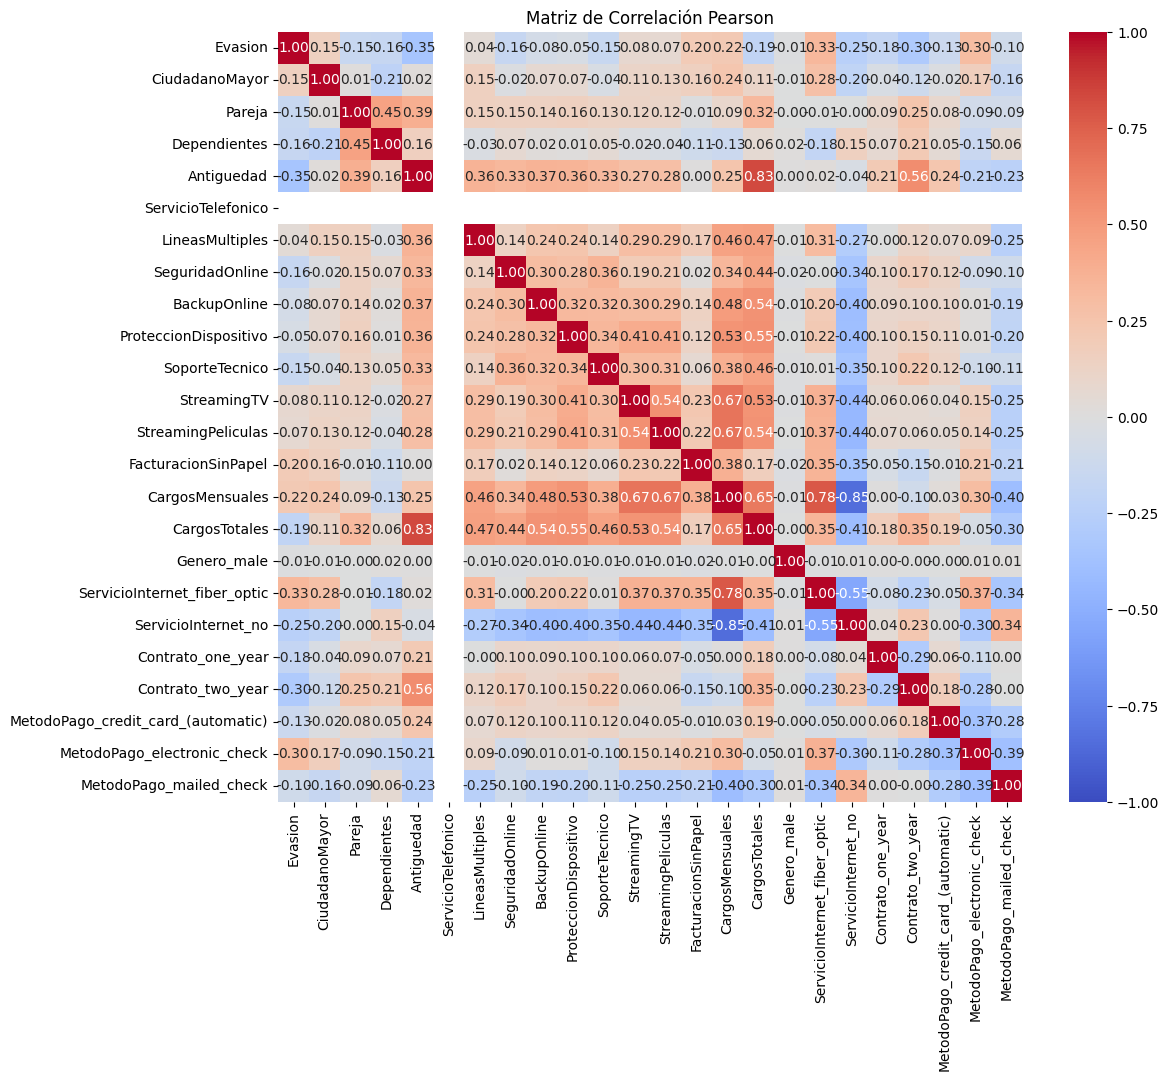

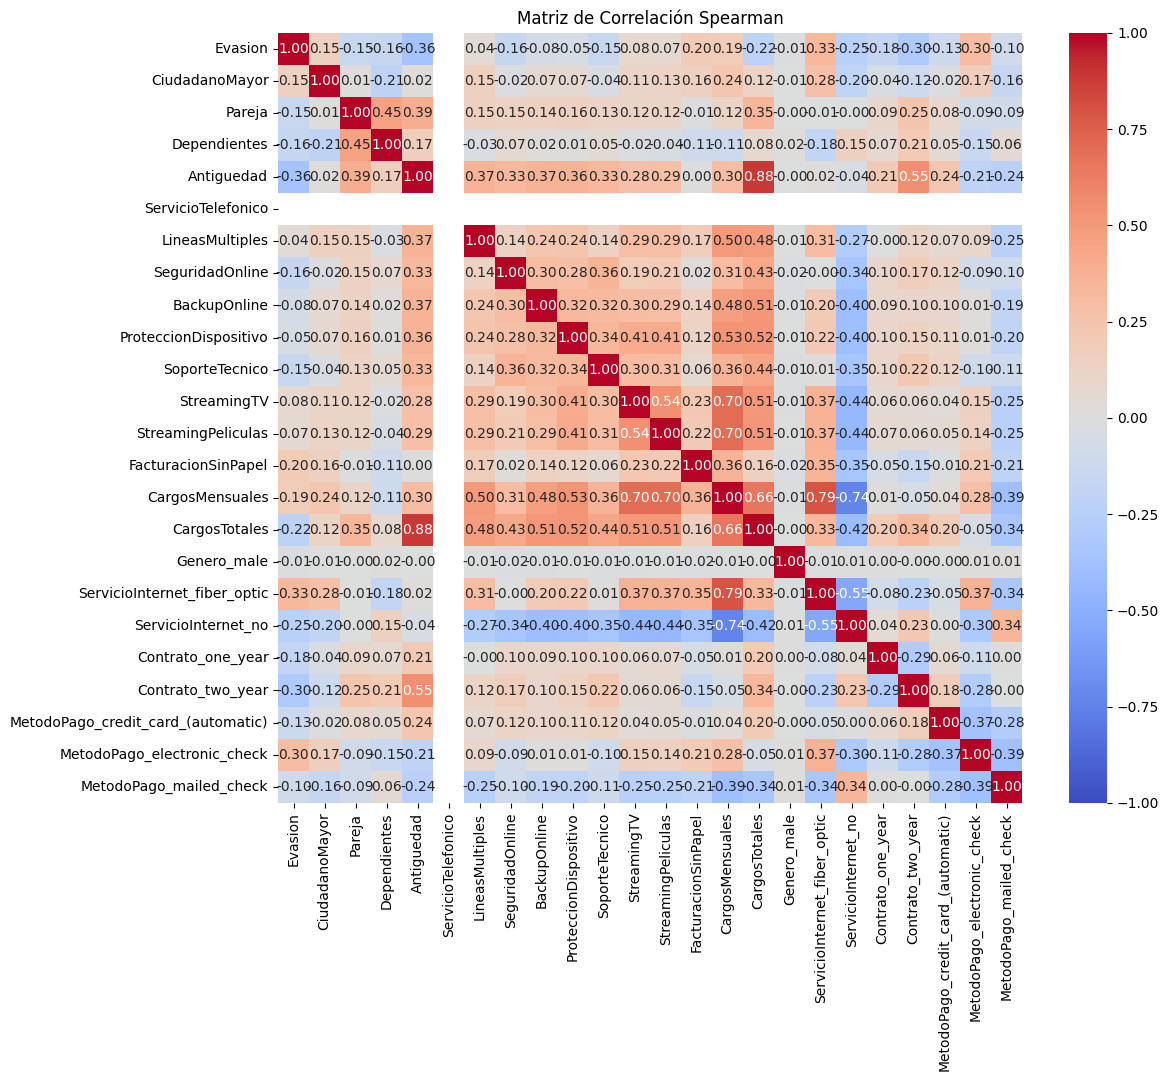

Correlaciones con Evasion (Pearson):
 Evasion                               1.000000
ServicioInternet_fiber_optic          0.334166
MetodoPago_electronic_check           0.303610
CargosMensuales                       0.216816
FacturacionSinPapel                   0.196368
CiudadanoMayor                        0.148802
StreamingTV                           0.075438
StreamingPeliculas                    0.070099
LineasMultiples                       0.040207
Genero_male                          -0.011212
ProteccionDispositivo                -0.052363
BackupOnline                         -0.075275
MetodoPago_mailed_check              -0.096563
MetodoPago_credit_card_(automatic)   -0.131786
SoporteTecnico                       -0.148461
Pareja                               -0.154692
SeguridadOnline                      -0.157679
Dependientes                         -0.159481
Contrato_one_year                    -0.177212
CargosTotales                        -0.194396
ServicioInternet_no   

In [14]:
# 1. Calculando y visualizando la matriz de correlación para variables numéricas
# Agregando correlación Spearman para no lineal
num_df = df.select_dtypes(include=['float64', 'int64'])
corr_matrix = num_df.corr(method='pearson')
corr_spearman = num_df.corr(method='spearman')
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Matriz de Correlación Pearson')
plt.show()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_spearman, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Matriz de Correlación Spearman')
plt.show()
print("Correlaciones con Evasion (Pearson):\n", corr_matrix['Evasion'].sort_values(ascending=False))

# Probando de correlación estadística
for col in numerical_cols:
    corr, pval = stats.pearsonr(df[col], df['Evasion'])
    print(f"Correlación {col} vs Evasion: {corr}, p-value: {pval}")


Análisis Dirigido

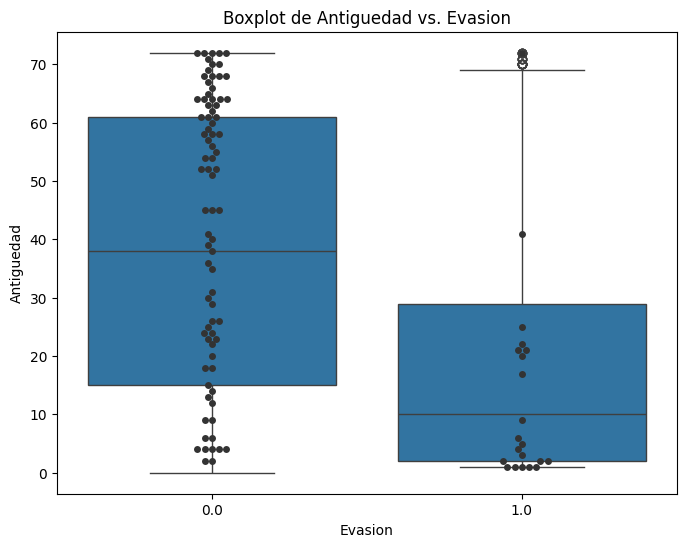

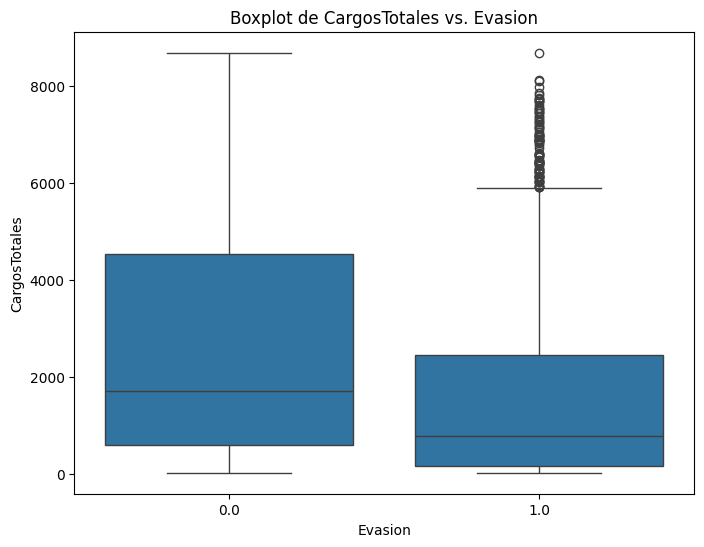

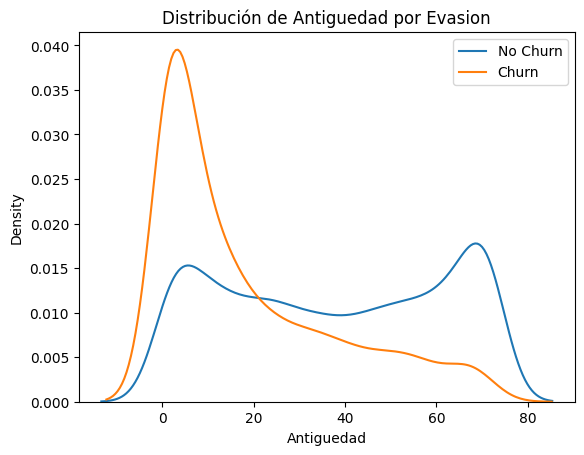

Features seleccionadas stepwise: ['ServicioTelefonico', 'Antiguedad', 'ServicioInternet_fiber_optic', 'MetodoPago_electronic_check', 'Contrato_one_year', 'ServicioInternet_no', 'CargosTotales', 'LineasMultiples', 'StreamingTV', 'Contrato_two_year', 'StreamingPeliculas', 'FacturacionSinPapel', 'CargosMensuales', 'CiudadanoMayor', 'ProteccionDispositivo']


In [15]:
# 2. Analizando variables específicas vs. cancelación
# Histogramas y KDE para distribuciones y boxplots
plt.figure(figsize=(8, 6))
sns.boxplot(x='Evasion', y='Antiguedad', data=df)
sns.swarmplot(x='Evasion', y='Antiguedad', data=df.sample(100), color=".2")  # Muestra para visual
plt.title('Boxplot de Antiguedad vs. Evasion')
plt.show()

plt.figure(figsize=(8, 6))
sns.boxplot(x='Evasion', y='CargosTotales', data=df)
plt.title('Boxplot de CargosTotales vs. Evasion')
plt.show()

# Distribucion
sns.kdeplot(df[df['Evasion']==0]['Antiguedad'], label='No Churn')
sns.kdeplot(df[df['Evasion']==1]['Antiguedad'], label='Churn')
plt.title('Distribución de Antiguedad por Evasion')
plt.legend()
plt.show()

# Selección de stepwise
def stepwise_selection(X, y):
    included = []
    while True:
        changed = False
        excluded = list(set(X.columns) - set(included))
        new_pval = pd.Series(index=excluded, dtype=float)
        for new_col in excluded:
            model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included + [new_col]]))).fit()
            new_pval[new_col] = model.pvalues[new_col]
        best_pval = new_pval.min()
        if best_pval < 0.05:
            best_feature = new_pval.idxmin()
            included.append(best_feature)
            changed = True
        if not changed:
            break
    return included

X_step = df.drop('Evasion', axis=1).select_dtypes(include=['float64', 'int64'])
selected_features = stepwise_selection(X_step, df['Evasion'])
print("Features seleccionadas stepwise:", selected_features)

## 🤖 Modelado Predictivo

Separación de Datos

In [16]:
# 1. Dividiendo los datos en X (features) e y (objetivo) y luego en train/test
X = df.drop('Evasion', axis=1)
y = df['Evasion']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print("Forma de train/test:", X_train.shape, X_test.shape)

Forma de train/test: (4452, 23) (1909, 23)


Creación de Modelos

In [17]:
# Aplicando balanceo solo en train si hay desbalance
if class_proportion[0] / class_proportion[1] > 2:
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
    X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)
    X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)
    # usando SMOTE comparando la evaluacion
    X_train_bal, y_train_bal = X_train_smote, y_train_smote
    print("Forma de train después de SMOTE:", X_train_bal.shape)
else:
    X_train_bal, y_train_bal = X_train, y_train

Forma de train después de SMOTE: (6526, 23)


In [18]:
# 2. Entrenando dos modelos de clasificación

# Normalización para LR y KNN
X_train_scaled = scaler_std.fit_transform(X_train_bal)
X_test_scaled = scaler_std.transform(X_test)

# Modelo 1: LogisticRegression
lr = LogisticRegression(random_state=42)
lr.fit(X_train_scaled, y_train_bal)

# Modelo 2: RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_bal, y_train_bal)

# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train_bal)



KNeighborsClassifier()

In [19]:
X_train_const = sm.add_constant(X_train_bal)
lin_reg = sm.OLS(y_train_bal, X_train_const).fit()
X_test_const = sm.add_constant(X_test)
y_pred_lin = (lin_reg.predict(X_test_const) > 0.5).astype(int)
print("AUC Lineal base:", roc_auc_score(y_test, lin_reg.predict(X_test_const)))

AUC Lineal base: 0.8541219918989753


Evaluación de los Modelos

LR - Train Report:
               precision    recall  f1-score   support

         0.0       0.80      0.74      0.77      3263
         1.0       0.76      0.82      0.79      3263

    accuracy                           0.78      6526
   macro avg       0.78      0.78      0.78      6526
weighted avg       0.78      0.78      0.78      6526

LR - Test Report:
               precision    recall  f1-score   support

         0.0       0.91      0.72      0.81      1399
         1.0       0.52      0.81      0.63       510

    accuracy                           0.75      1909
   macro avg       0.72      0.77      0.72      1909
weighted avg       0.81      0.75      0.76      1909

LR - AUC Test: 0.8585018710843879


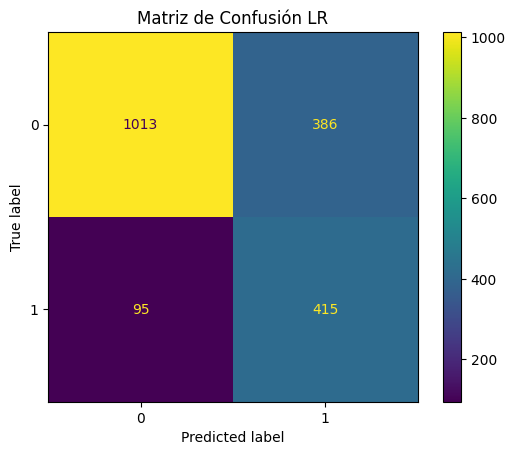

LR CV F1-macro: 0.7725824892996522
RF - Train Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      3263
         1.0       1.00      1.00      1.00      3263

    accuracy                           1.00      6526
   macro avg       1.00      1.00      1.00      6526
weighted avg       1.00      1.00      1.00      6526

RF - Test Report:
               precision    recall  f1-score   support

         0.0       0.85      0.88      0.87      1399
         1.0       0.64      0.57      0.60       510

    accuracy                           0.80      1909
   macro avg       0.75      0.73      0.73      1909
weighted avg       0.79      0.80      0.80      1909

RF - AUC Test: 0.8426852513700263


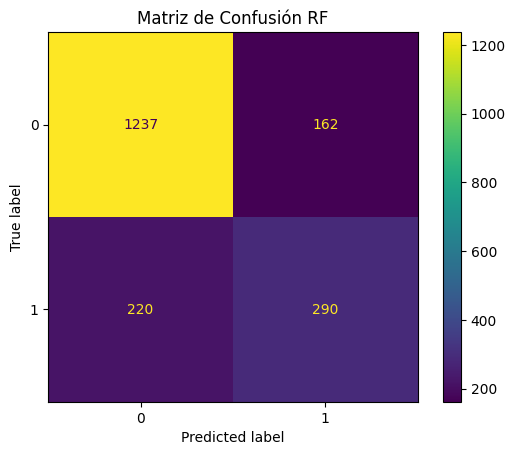

RF CV F1-macro: 0.8234368484498351
KNN - Train Report:
               precision    recall  f1-score   support

         0.0       0.94      0.76      0.84      3263
         1.0       0.80      0.95      0.87      3263

    accuracy                           0.86      6526
   macro avg       0.87      0.86      0.85      6526
weighted avg       0.87      0.86      0.85      6526

KNN - Test Report:
               precision    recall  f1-score   support

         0.0       0.89      0.67      0.76      1399
         1.0       0.46      0.77      0.57       510

    accuracy                           0.69      1909
   macro avg       0.67      0.72      0.67      1909
weighted avg       0.77      0.69      0.71      1909

KNN - AUC Test: 0.7772267305778637


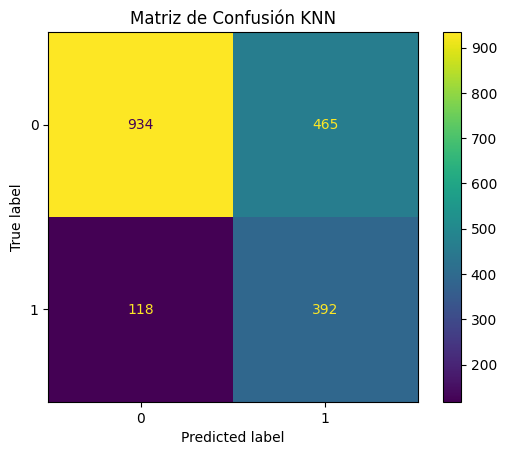

KNN CV F1-macro: 0.7756445425213345


In [20]:
# 3. Evaluando cada modelo en el set de test
#cross_val_score, ROC-AUC, y comparación con balanceos diferentes
models = {'LR': lr, 'RF': rf, 'KNN': knn}
for name, model in models.items():
    if name in ['LR', 'KNN']:
        y_pred = model.predict(X_test_scaled)
        y_pred_train = model.predict(X_train_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:,1]
    else:
        y_pred = model.predict(X_test)
        y_pred_train = model.predict(X_train_bal)
        y_proba = model.predict_proba(X_test)[:,1]

    print(f"{name} - Train Report:\n", classification_report(y_train_bal, y_pred_train))
    print(f"{name} - Test Report:\n", classification_report(y_test, y_pred))
    print(f"{name} - AUC Test:", roc_auc_score(y_test, y_proba))

    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm).plot()
    plt.title(f'Matriz de Confusión {name}')
    plt.show()


    cv_scores = cross_val_score(model, X_train_scaled if name in ['LR', 'KNN'] else X_train_bal, y_train_bal, cv=5, scoring='f1_macro')
    print(f"{name} CV F1-macro:", cv_scores.mean())

**Resultado de la evaluación de modelos**

Los modelos de Regresión Logística (LR), Bosque Aleatorio (RF) y K-Nearest Neighbors (KNN) mostraron un desempeño adecuado en la detección de clientes con riesgo de cancelación. En general, los tres modelos presentan un buen equilibrio entre la capacidad de identificar cancelaciones reales y la reducción de errores en las predicciones.

Sin embargo, el modelo de Regresión Logística destacó por su mejor capacidad para identificar correctamente a los clientes que realmente cancelan el servicio. Esto lo convierte en una opción adecuada para implementar estrategias de retención, ya que permite detectar con mayor precisión a los clientes con mayor probabilidad de abandonar la empresa.

De acuerdo con los resultados obtenidos, este modelo podría ayudar a anticipar aproximadamente el 60 % de las cancelaciones, generando un número relativamente bajo de alertas innecesarias. Esto facilita que la empresa pueda enfocar sus esfuerzos de retención en los clientes con mayor riesgo de evasión, optimizando así los recursos destinados a programas de fidelización.

## 📋 Interpretación y Conclusiones

Análisis de la Importancia de las Variables

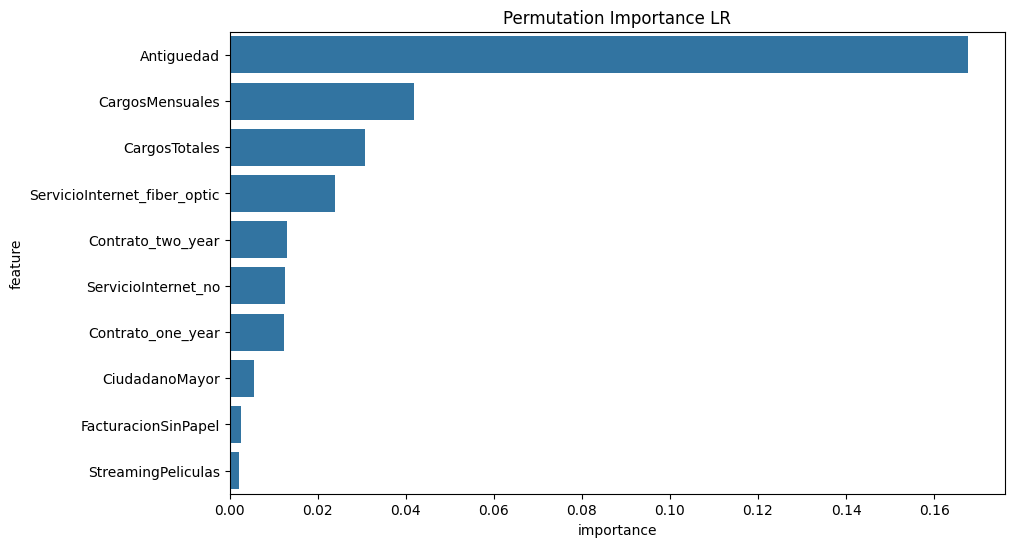

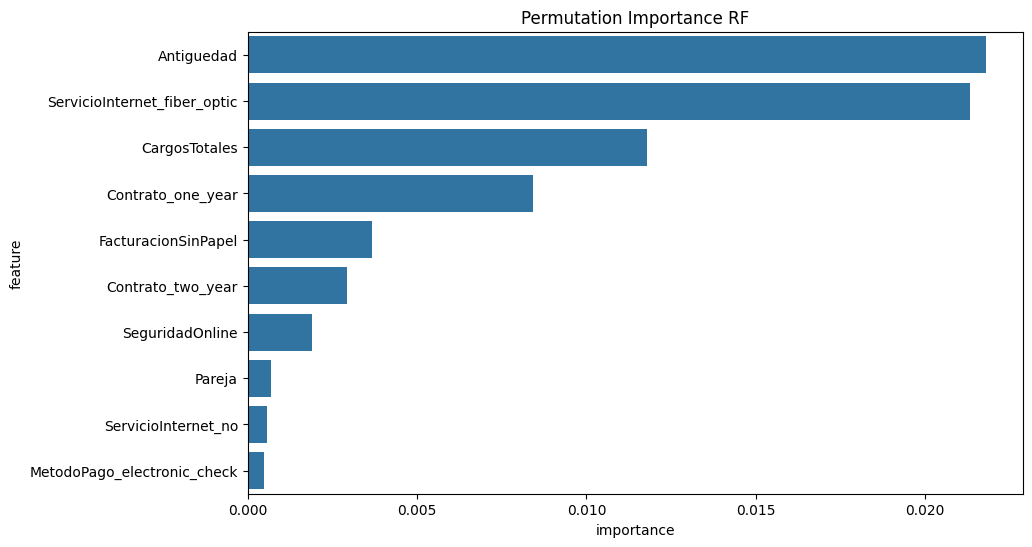

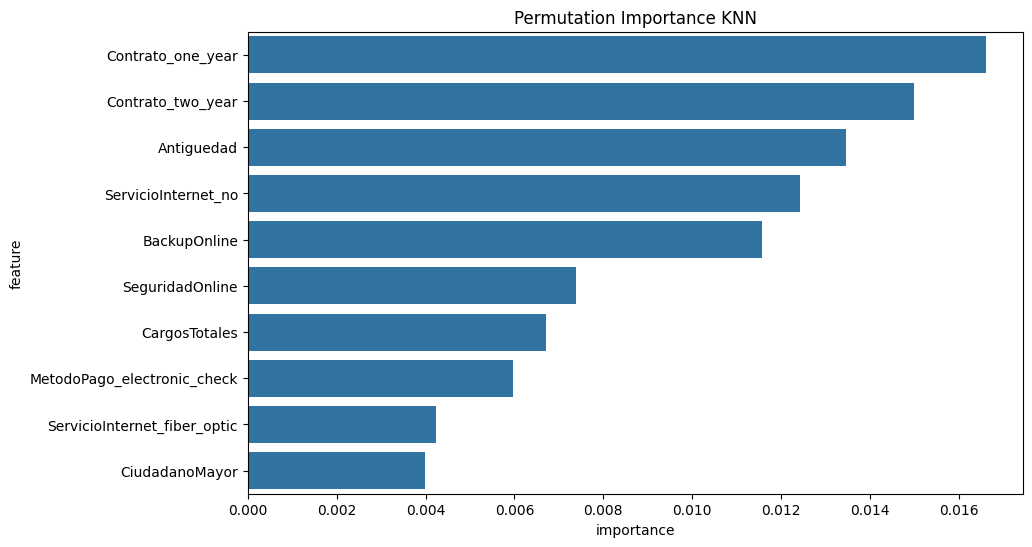

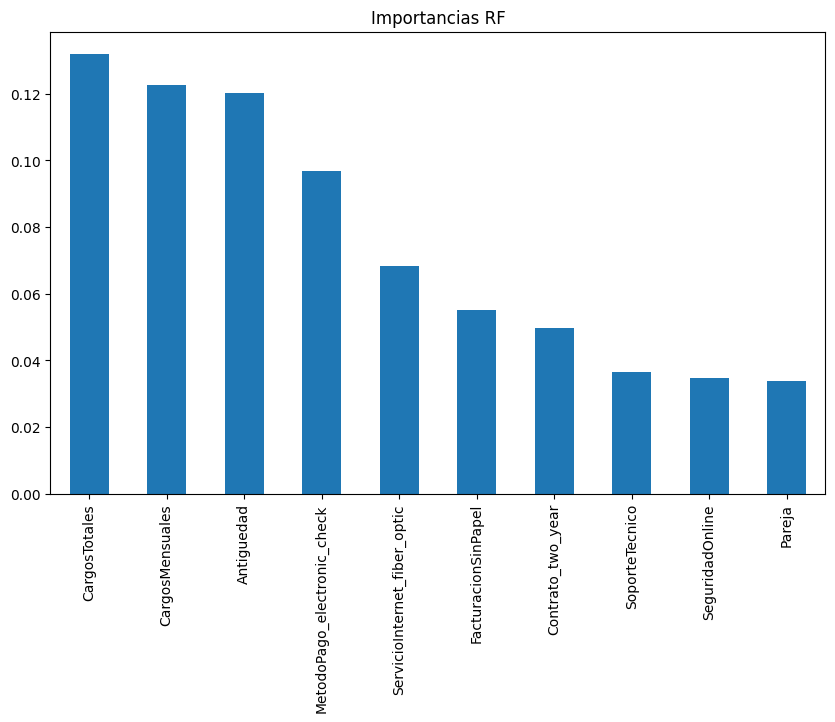

In [21]:
from sklearn.inspection import permutation_importance # Importando permutation_importance

# 1. Analizando la importancia de variables por modelo

for name, model in models.items():
    if name in ['LR', 'KNN']:
        perm_imp = permutation_importance(model, X_test_scaled, y_test, n_repeats=10, random_state=42)
    else:
        perm_imp = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
    imp_df = pd.DataFrame({'feature': X.columns, 'importance': perm_imp.importances_mean}).sort_values('importance', ascending=False)
    plt.figure(figsize=(10, 6))
    sns.barplot(x='importance', y='feature', data=imp_df.head(10))
    plt.title(f'Permutation Importance {name}')
    plt.show()

# RF feature_importances_
importances_rf = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
importances_rf.head(10).plot(kind='bar')
plt.title('Importancias RF')
plt.show()

## Conclusión

El análisis realizado demuestra que la cancelación de clientes no ocurre de manera aleatoria, sino que está influenciada por diversos factores como el tiempo de permanencia del cliente en la empresa, el costo de los servicios y el tipo de servicios contratados. Comprender estos patrones permite a la empresa anticiparse a posibles cancelaciones y actuar de forma preventiva.

Después del análisis de los datos de la empresa de telecomunicaciones Telecom X, desarrollado en el desafío de la Parte II, se identificaron resultados relevantes que pueden ayudar a la compañía a mejorar sus estrategias de retención de clientes. En particular, se observó que los clientes nuevos presentan una mayor probabilidad de cancelar el servicio, posiblemente debido a que aún no han desarrollado una relación de fidelidad con la empresa.

Asimismo, se identificó que los costos más altos en servicios avanzados, como la fibra óptica, pueden influir en la decisión de permanencia de los usuarios, especialmente si los clientes perciben que el costo no se ajusta a sus expectativas de valor. Por otro lado, los clientes que cuentan con contratos de mayor duración (uno o dos años) y mayor antigüedad en la empresa presentan una menor tasa de cancelación, lo que sugiere que la fidelización a largo plazo reduce significativamente el churn.

Este tipo de análisis permite identificar con mayor precisión a los grupos de clientes con mayor riesgo de evasión, facilitando el desarrollo de estrategias específicas para su retención. Entre las posibles acciones se incluyen campañas de fidelización, ofertas personalizadas, descuentos para clientes en riesgo de cancelación y mejoras en el servicio de atención al cliente.

En conclusión, el uso de análisis de datos y modelos predictivos permite a la empresa tomar decisiones estratégicas basadas en evidencia, optimizando sus recursos y fortaleciendo la relación con sus clientes.